<a href="https://colab.research.google.com/github/sec23cb084-stack/Astma-Youtube/blob/main/Astma_Youtube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import nltk
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from textblob import TextBlob
import matplotlib.pyplot as plt

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
# Read dataset
df = pd.read_csv("covid_2021_1.csv")

# Print column names
print("Columns in Dataset:")
print(df.columns)

# Select the correct comment column
comment_col = df.columns[0]   # Change index if needed

print("Using column:", comment_col)

# Remove null values
df = df.dropna(subset=[comment_col])


Columns in Dataset:
Index(['query', 'url', 'title', 'upload_date', 'channel', 'views', 'likes',
       'dislikes', 'comment_count', 'comment_text', 'comment_author',
       'comment_date', 'comment_likes', 'DATE'],
      dtype='object')
Using column: query


In [6]:
# Cleaning
df['Cleaned_Comment'] = df[comment_col].astype(str).str.lower()

df['Cleaned_Comment'] = df['Cleaned_Comment'].apply(
    lambda x: re.sub(r'http\S+|www\S+', '', x)
)

df['Cleaned_Comment'] = df['Cleaned_Comment'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)

df['Cleaned_Comment'] = df['Cleaned_Comment'].apply(
    lambda x: re.sub(r'\d+', '', x)
)


In [8]:
# Simple tokenization without NLTK
df['Tokens'] = df['Cleaned_Comment'].apply(lambda x: x.split())

print(df['Tokens'].head())

0    [coronaviruscovidcpandemicvaccine]
1    [coronaviruscovidcpandemicvaccine]
2    [coronaviruscovidcpandemicvaccine]
3    [coronaviruscovidcpandemicvaccine]
4    [coronaviruscovidcpandemicvaccine]
Name: Tokens, dtype: object


In [9]:
# Sentiment Analysis
def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df['Sentiment'] = df['Cleaned_Comment'].apply(get_sentiment)


In [10]:
# Percentage calculation
sentiment_counts = df['Sentiment'].value_counts()

total = len(df)

positive = sentiment_counts.get('Positive', 0) / total * 100
negative = sentiment_counts.get('Negative', 0) / total * 100
neutral = sentiment_counts.get('Neutral', 0) / total * 100

print("\nPositive:", round(positive, 2), "%")
print("Negative:", round(negative, 2), "%")
print("Neutral :", round(neutral, 2), "%")



Positive: 0.0 %
Negative: 0.0 %
Neutral : 100.0 %


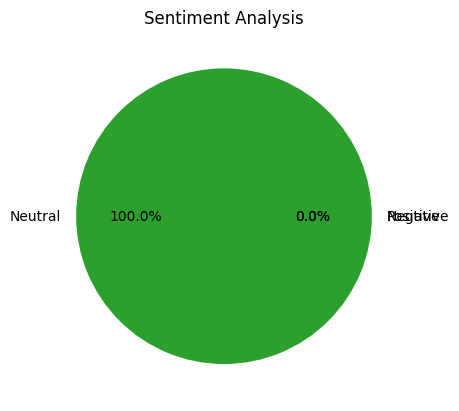

In [11]:
# Visualization
labels = ['Positive', 'Negative', 'Neutral']
values = [positive, negative, neutral]

plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Sentiment Analysis")
plt.show()